# Libraries

In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Rescaling
from keras.models import Sequential
from keras.optimizers import Adam

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Load data

Load it in grayscale.

In [ ]:
# It is important to keep shuffle to False so we can have consistency when parsing the images
# We will shuffle on training

train_ds = tf.keras.utils.image_dataset_from_directory('data/x-rays/train/', color_mode='grayscale', shuffle=False)
val_ds = tf.keras.utils.image_dataset_from_directory('data/x-rays/validation/', color_mode='grayscale', shuffle=False)

Found 351 files belonging to 3 classes.
Found 90 files belonging to 3 classes.


In [6]:
class_names = train_ds.class_names
class_names

['COVID-19', 'HEALTHY', 'PNEUMONIA']

2025-11-25 13:41:39.938420: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


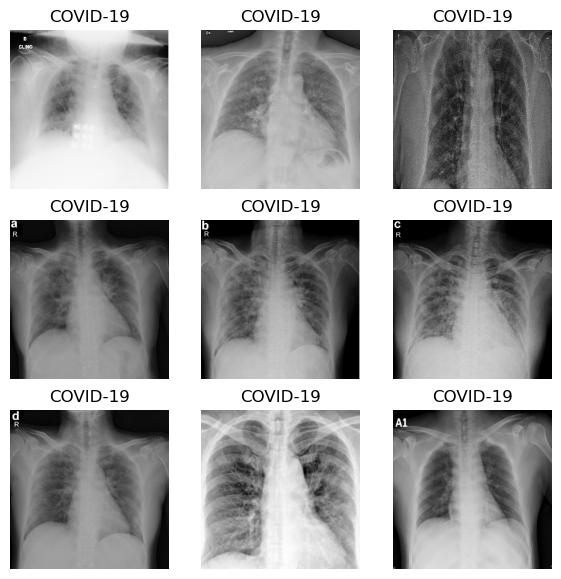

In [7]:
# Display image samples
plt.figure(figsize=(7, 7))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis('off')

# Functions

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import glob
import os

def generate_submission(model, leaderboard_folder, submission_path, is_grayscale=False):
    paths = sorted(glob.glob(os.path.join(leaderboard_folder, "*")))
    imgs = []
    names = []

    for p in paths:
        if is_grayscale:
            img = load_img(p, target_size=(256, 256), color_mode='grayscale')  # CAST!
        else:
            img = load_img(p, target_size=(256, 256))  # CAST!
        names.append(int(os.path.splitext(os.path.basename(p))[0]))
        imgs.append(img_to_array(img))

    X_lb = np.array(imgs)
    predictions = model.predict(X_lb, verbose=0)
    if predictions.shape[1] > 1:
        predictions = predictions.argmax(axis=1)

    submission_df = pd.DataFrame({
        'id': names,
        'prediction': predictions
    }).sort_values('id')

    submission_df.to_csv(submission_path, index=False)

In [9]:
# Image shapes
images[i].shape

TensorShape([256, 256, 1])

# CNN

## Grayscale

Keras can directly load data from a structure of directories, we don't need the pandas DataFrame we were using before.

The following example is not working well. Improve it! For example, adding more convolutional layer and/or more filters, etc.

In [49]:
cnn_model = Sequential([
    Input(shape=(256, 256, 1)),
    Rescaling(1./255),
    Conv2D(filters=2, kernel_size=2, strides=1, activation='relu'),
    MaxPooling2D(pool_size=2, strides=None),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

cnn_model.compile(optimizer=Adam(learning_rate=0.01),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [50]:
cnn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 255, 255, 2)    │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 127, 127, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32258)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │     1,032,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,032,397 (3.94 MB)

 Trainable params: 1,032,397 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
cnn_model.fit(train_ds, validation_data=val_ds, epochs=5, shuffle=True)

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.2764 - loss: 7.0489 - val_accuracy: 0.3333 - val_loss: 1.0768
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3362 - loss: 1.0762 - val_accuracy: 0.3333 - val_loss: 1.0434
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4587 - loss: 1.0184 - val_accuracy: 0.4444 - val_loss: 1.0138
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5014 - loss: 0.9720 - val_accuracy: 0.4667 - val_loss: 0.9979
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5071 - loss: 0.9334 - val_accuracy: 0.4778 - val_loss: 0.9818


In [52]:
loss, acc = cnn_model.evaluate(val_ds, verbose=0)
print('Validation accuracy:', round(acc, 2))

Validation accuracy: 0.48


In [55]:
# Keras returns predicted probabilities by default

y_val_pred_probs = cnn_model.predict(val_ds, verbose=0)
y_val_pred_probs[:5]

array([[0.3389802 , 0.31031615, 0.35070366],
       [0.3389802 , 0.31031615, 0.35070366],
       [0.3389802 , 0.31031615, 0.35070366],
       [0.3389802 , 0.31031615, 0.35070366],
       [0.3389802 , 0.31031615, 0.35070366]], dtype=float32)

In [54]:
# Convert probabilities to class predictions
y_val_pred = y_val_pred_probs.argmax(axis=1)
y_val_pred[:5]

array([2, 2, 2, 2, 2])

In [56]:
# Extract true labels from the validation dataset
y_val = np.concatenate([y for _, y in val_ds], axis=0)

In [57]:
print(classification_report(y_val, y_val_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        30
           1       0.58      0.93      0.72        30
           2       0.36      0.50      0.42        30

    accuracy                           0.48        90
   macro avg       0.31      0.48      0.38        90
weighted avg       0.31      0.48      0.38        90



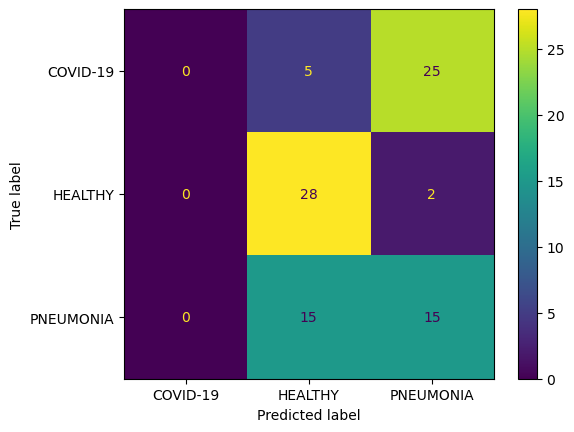

In [58]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
plt.xticks(range(3), val_ds.class_names)
plt.yticks(range(3), val_ds.class_names)
plt.show()

## Submission

In [ ]:
generate_submission(
    cnn_model,
    leaderboard_folder='data/x-rays/leaderboard',
    submission_path='data/x-rays/submission_cnn.csv',
    is_grayscale=True
)

## RGB

Same example as before, but working with RGB images instead.

In this case, we just need to specify we are receiving an input of (256, 256, 3).

In [59]:
train_rgb_ds = tf.keras.utils.image_dataset_from_directory('data/x-rays/train/', shuffle=False)
val_rgb_ds = tf.keras.utils.image_dataset_from_directory('data/x-rays/validation/', shuffle=False)

Found 351 files belonging to 3 classes.
Found 90 files belonging to 3 classes.


In [ ]:
cnn_rgb_model = Sequential([
    Input(shape=(256, 256, 3)),
    Rescaling(1./255),
    Conv2D(filters=3, kernel_size=2, strides=1, activation='relu'),
    MaxPooling2D(pool_size=2, strides=None),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

cnn_rgb_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
cnn_rgb_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 255, 255, 3)    │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 127, 127, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 48387)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │     1,548,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,548,554 (5.91 MB)

 Trainable params: 1,548,554 (5.91 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_rgb_model.fit(train_rgb_ds, validation_data=val_rgb_ds, epochs=5, shuffle=True)

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.2593 - loss: 12.3696 - val_accuracy: 0.3333 - val_loss: 4.3100
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.5755 - loss: 2.2599 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.3333 - loss: 1.0984 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.3333 - loss: 1.0988 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.3333 - loss: 1.0989 - val_accuracy: 0.3333 - val_loss: 1.0986


In [ ]:
loss, acc = cnn_rgb_model.evaluate(val_rgb_ds, verbose=0)
print('Validation accuracy:', round(acc, 2))

Validation accuracy: 0.33


In [42]:
# Convert probabilities to class predictions
y_val_pred = y_val_pred_probs.argmax(axis=1)
y_val_pred[:5]

array([0, 0, 0, 0, 0])

In [43]:
# Extract true labels from the validation dataset
y_val = np.concatenate([y for _, y in val_ds], axis=0)

In [44]:
print(classification_report(y_val, y_val_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.82      0.93      0.88        30
           1       0.82      0.77      0.79        30
           2       0.75      0.70      0.72        30

    accuracy                           0.80        90
   macro avg       0.80      0.80      0.80        90
weighted avg       0.80      0.80      0.80        90



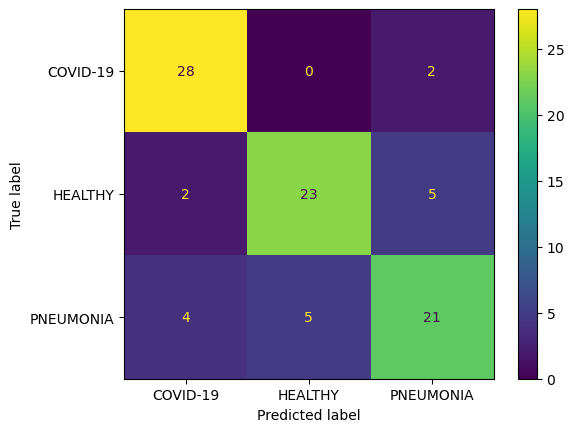

In [45]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
plt.xticks(range(3), val_ds.class_names)
plt.yticks(range(3), val_ds.class_names)
plt.show()

## Submission

In [ ]:
generate_submission(
    cnn_rgb_model,
    leaderboard_folder='data/x-rays/leaderboard',
    submission_path='data/x-rays/submission_cnn_rgb.csv',
    is_grayscale=False
)